<a href="https://colab.research.google.com/github/Mariem-mcs/Lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

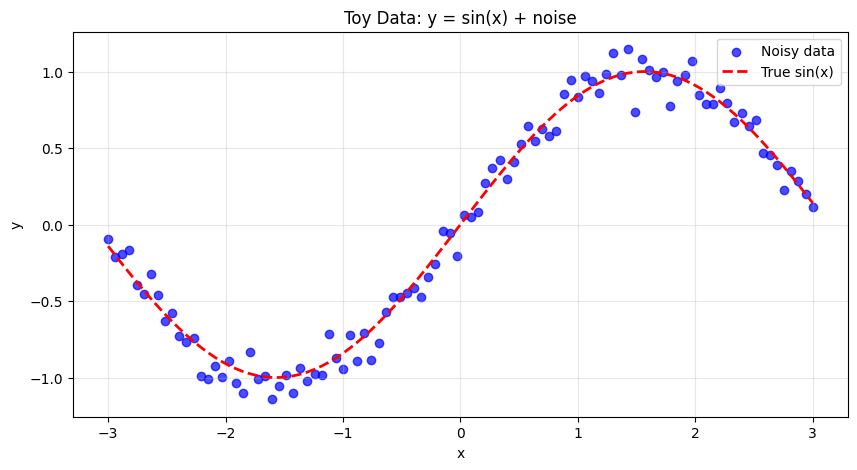

Generated 100 samples with noise


In [4]:
# TODO: Generating the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
 # For reproducibility
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Ploting the data:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.7, label='Noisy data', color='blue')
plt.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data: y = sin(x) + noise')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Generated {len(x)} samples with noise")

In [3]:
# TODO: Initialising w and b to small random values
np.random.seed(42)
# The small random weight:
w = np.random.randn() * 0.1
# The small random bias :
b = np.random.randn() * 0.1

# Hyperparameters:
learning_rate = 0.1
epochs = 200
# Lists to store history:
loss_history = []
w_history = []
b_history = []
print(f"Initial: w = {w:.4f}, b = {b:.4f}")

Initial: w = 0.0497, b = -0.0138


In [5]:
# TODO: Implementing ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
for epoch in range(epochs):
    y_pred = w * x + b
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)
    dw = np.mean(2 * (y_pred - y) * x)
    db = np.mean(2 * (y_pred - y))
    w -= learning_rate * dw
    b -= learning_rate * db
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.6f}, w = {w:.4f}, b = {b:.4f}")

Epoch  20: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch  40: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch  60: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch  80: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 100: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 120: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 140: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 160: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 180: Loss = 0.195452, w = 0.3390, b = -0.0104
Epoch 200: Loss = 0.195452, w = 0.3390, b = -0.0104


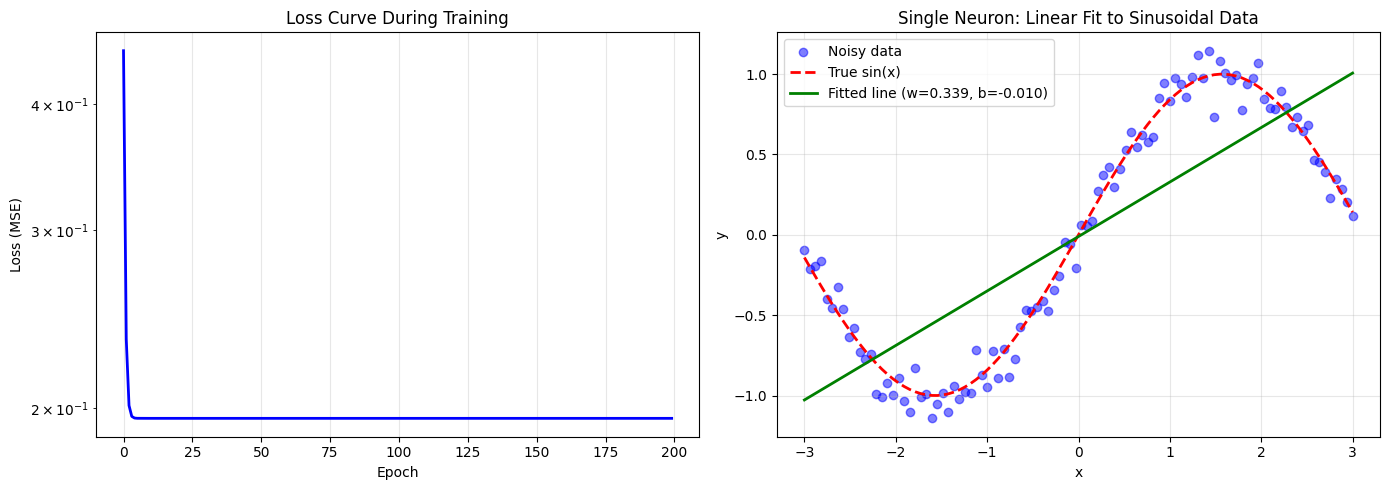

OBSERVATIONS:
1. Final Loss: 0.195452
2. The line cannot fit the curve (underfitting)
3. A single neuron is a linear model - it can only learn straight lines
4. Loss improved but plateaued because the model is too simple


In [7]:
# TODO: Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# (a) the loss curve over the 200 steps:
ax1 = axes[0]
ax1.plot(loss_history, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Curve During Training')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# (b) the data with the fitted line on top:
ax2 = axes[1]
ax2.scatter(x, y, alpha=0.5, label='Noisy data', color='blue')
ax2.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
ax2.plot(x, w * x + b, 'g-', label=f'Fitted line (w={w:.3f}, b={b:.3f})', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Single Neuron: Linear Fit to Sinusoidal Data')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*50)
print("OBSERVATIONS:")
print("="*50)
print(f"1. Final Loss: {loss_history[-1]:.6f}")
print(f"2. The line cannot fit the curve (underfitting)")
print(f"3. A single neuron is a linear model - it can only learn straight lines")
print(f"4. Loss improved but plateaued because the model is too simple")

Part 1.2 — Hidden layers and activations: why depth helps

In [8]:
# TODO: Initializing the parameters:
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
np.random.seed(42)
input_size = 1
hidden_size = 8
output_size = 1
# Initializing weights and biases with small random values:
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.random.randn(hidden_size) * 0.5
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.random.randn(output_size) * 0.5

print("Parameters initialized:")
print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")

Parameters initialized:
W1 shape: (1, 8)
b1 shape: (8,)
W2 shape: (8, 1)
b2 shape: (1,)


In [9]:
# TODO: Forwarding the pass (keep the intermediate values — you need them for backprop):
#Hint:
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

def forward_pass(x, W1, b1, W2, b2, use_tanh=True):
    z1 = x @ W1 + b1
    if use_tanh:
        h = np.tanh(z1)
    else:
        h = z1
    y_hat = h @ W2 + b2
    return z1, h, y_hat

# Testing the the forward pass:
z1, h, y_hat = forward_pass(x.reshape(-1, 1), W1, b1, W2, b2, use_tanh=True)
print("Forward pass successful")
print(f"x shape: {x.reshape(-1, 1).shape}")
print(f"z1 shape: {z1.shape}")
print(f"h shape: {h.shape}")
print(f"y_hat shape: {y_hat.shape}")

Forward pass successful
x shape: (100, 1)
z1 shape: (100, 8)
h shape: (100, 8)
y_hat shape: (100, 1)


In [19]:
# TODO: Backward pass (the chain rule, layer by layer):
#Hint:
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

np.random.seed(42)
# Generating data:
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, (100, 1))

# Initializing the parameters first:
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
print("="*50)
print("INITIALIZATION COMPLETE")
print("="*50)
print(f"x shape: {x.shape}, y shape: {y.shape}")
print(f"W1: {W1.shape}, b1: {b1.shape}")
print(f"W2: {W2.shape}, b2: {b2.shape}")
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

print("\n" + "="*50)
print("BACKWARD PASS COMPLETE")
print("="*50)
print(f"d_yhat shape: {d_yhat.shape}")
print(f"dW2 shape:    {dW2.shape} ")
print(f"db2 shape:    {db2.shape}")
print(f"dh shape:     {dh.shape}")
print(f"dz1 shape:    {dz1.shape}")
print(f"dW1 shape:    {dW1.shape}")
print(f"db1 shape:    {db1.shape}")



INITIALIZATION COMPLETE
x shape: (100, 1), y shape: (100, 1)
W1: (1, 8), b1: (8,)
W2: (8, 1), b2: (1,)

BACKWARD PASS COMPLETE
d_yhat shape: (100, 1)
dW2 shape:    (8, 1) 
db2 shape:    (1,)
dh shape:     (100, 8)
dz1 shape:    (100, 8)
dW1 shape:    (1, 8)
db1 shape:    (8,)


In [20]:
# TODO: Update all parameters with learning rate lr, loop for ~3000 steps
learning_rate = 0.01
epochs = 3000
loss_history = []
for epoch in range(epochs):
    #The fORWARD PASS:
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    # Recording the loss:
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # The BACKWARD PASS:
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    #UPDATE PARAMETERS:
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d}: Loss = {loss:.6f}")
print(f"Training complete! Final Loss = {loss_history[-1]:.6f}")


Epoch  500: Loss = 0.036206
Epoch 1000: Loss = 0.026037
Epoch 1500: Loss = 0.023112
Epoch 2000: Loss = 0.021666
Epoch 2500: Loss = 0.020614
Epoch 3000: Loss = 0.019750
Training complete! Final Loss = 0.019750


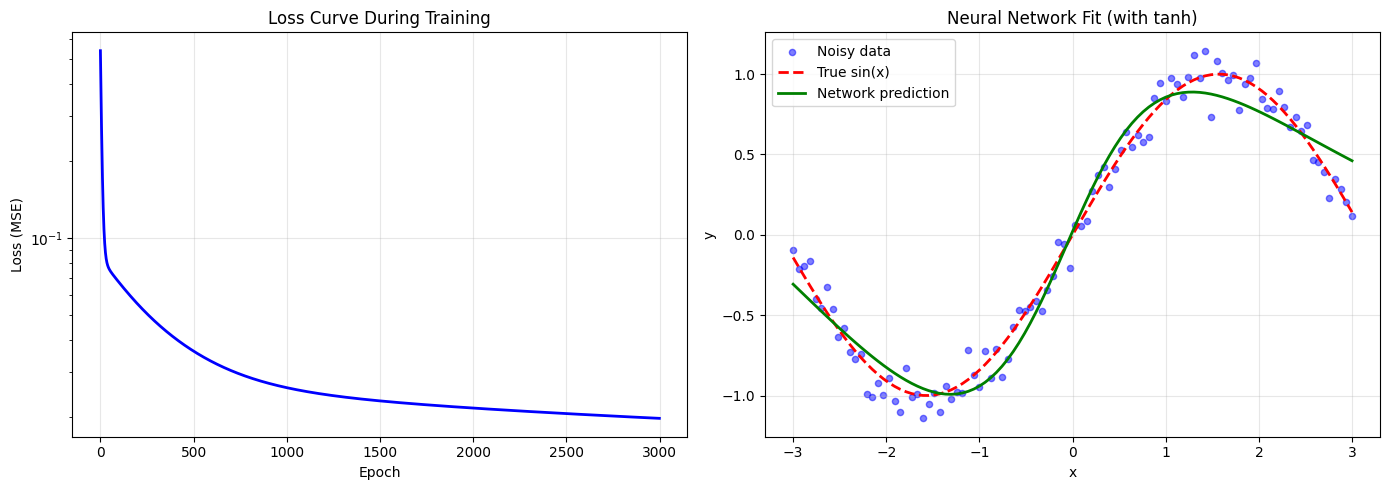

SUMMARY
Initial Loss:  0.540648
Final Loss:    0.019750
Improvement:   0.520898


In [21]:
# TODO: Plot the loss curve AND the final fit over the data.
z1_final = x @ W1 + b1
h_final = np.tanh(z1_final)
y_pred_final = h_final @ W2 + b2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curve
ax1 = axes[0]
ax1.plot(loss_history, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Curve During Training')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Data with fitted curve
ax2 = axes[1]
ax2.scatter(x, y, alpha=0.5, label='Noisy data', color='blue', s=20)
ax2.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
ax2.plot(x, y_pred_final, 'g-', label='Network prediction', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Neural Network Fit (with tanh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*50)
print("SUMMARY")
print("="*50)
print(f"Initial Loss:  {loss_history[0]:.6f}")
print(f"Final Loss:    {loss_history[-1]:.6f}")
print(f"Improvement:   {loss_history[0] - loss_history[-1]:.6f}")

TRAINING WITHOUT TANH ACTIVATION
This means: h = z1 (no activation, linear)
Epoch  500: Loss = 0.195452
Epoch 1000: Loss = 0.195452
Epoch 1500: Loss = 0.195452
Epoch 2000: Loss = 0.195452
Epoch 2500: Loss = 0.195452
Epoch 3000: Loss = 0.195452
Training complete! Final Loss = 0.195452


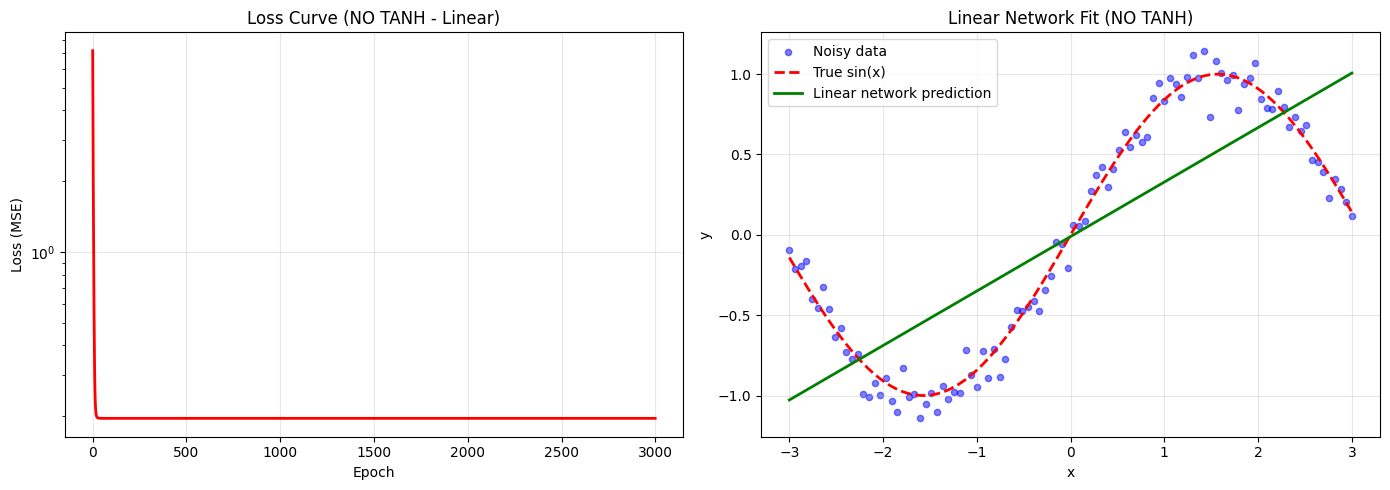

In [22]:
# RE-RUN WITH TANH REMOVED (h = z1)
print("="*50)
print("TRAINING WITHOUT TANH ACTIVATION")
print("="*50)
print("This means: h = z1 (no activation, linear)")

# Re-initializing the parameters:
np.random.seed(42)
W1_no = np.random.randn(1, 8) * 0.5
b1_no = np.random.randn(8) * 0.5
W2_no = np.random.randn(8, 1) * 0.5
b2_no = np.random.randn(1) * 0.5

learning_rate = 0.01
epochs = 3000
loss_history_no = []

for epoch in range(epochs):
    z1 = x @ W1_no + b1_no
    h = z1
    y_hat = h @ W2_no + b2_no

    loss = np.mean((y_hat - y) ** 2)
    loss_history_no.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2_no.T
    dz1 = dh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    W1_no -= learning_rate * dW1
    b1_no -= learning_rate * db1
    W2_no -= learning_rate * dW2
    b2_no -= learning_rate * db2

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d}: Loss = {loss:.6f}")

print(f"Training complete! Final Loss = {loss_history_no[-1]:.6f}")

# PLOT RESULTS WITHOUT TANH
z1_final_no = x @ W1_no + b1_no
h_final_no = z1_final_no          # No activation
y_pred_final_no = h_final_no @ W2_no + b2_no
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1 = axes[0]
ax1.plot(loss_history_no, 'r-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Curve (NO TANH - Linear)')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Data with fitted line
ax2 = axes[1]
ax2.scatter(x, y, alpha=0.5, label='Noisy data', color='blue', s=20)
ax2.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
ax2.plot(x, y_pred_final_no, 'g-', label='Linear network prediction', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Linear Network Fit (NO TANH)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

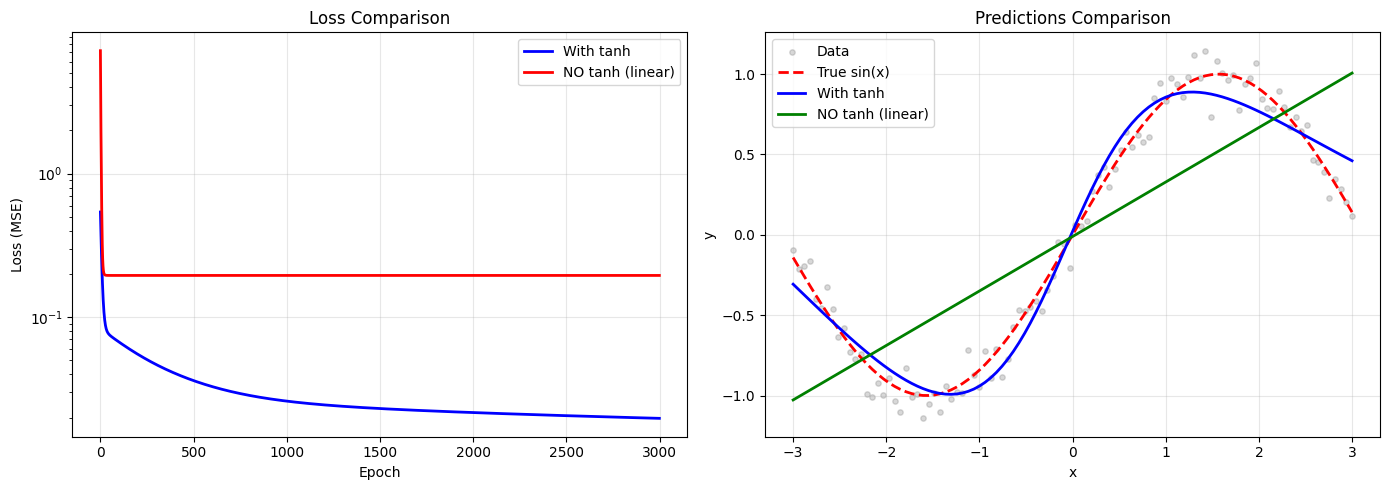

FINAL COMPARISON
With tanh - Final Loss:    0.019750
NO tanh - Final Loss:      0.195452
Difference:                 0.175702

CONCLUSION:
Without tanh (linear), the network cannot fit the sine wave.
With tanh, the network learns the non-linear shape.
This proves that activation functions are essential for neural networks!


In [23]:
# COMPARAISON: WITH TANH vs WITHOUT TANH
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1 = axes[0]
ax1.plot(loss_history, 'b-', label='With tanh', linewidth=2)
ax1.plot(loss_history_no, 'r-', label='NO tanh (linear)', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
ax2 = axes[1]
ax2.scatter(x, y, alpha=0.3, label='Data', color='gray', s=15)
ax2.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)

# With tanh:
z1_t = x @ W1 + b1
h_t = np.tanh(z1_t)
y_pred_t = h_t @ W2 + b2
ax2.plot(x, y_pred_t, 'b-', label='With tanh', linewidth=2)

# Without tanh:
z1_nt = x @ W1_no + b1_no
h_nt = z1_nt
y_pred_nt = h_nt @ W2_no + b2_no
ax2.plot(x, y_pred_nt, 'g-', label='NO tanh (linear)', linewidth=2)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Predictions Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*50)
print("FINAL COMPARISON")
print("="*50)
print(f"With tanh - Final Loss:    {loss_history[-1]:.6f}")
print(f"NO tanh - Final Loss:      {loss_history_no[-1]:.6f}")
print(f"Difference:                 {loss_history_no[-1] - loss_history[-1]:.6f}")
print("\n" + "="*50)
print("CONCLUSION:")
print("="*50)
print("Without tanh (linear), the network cannot fit the sine wave.")
print("With tanh, the network learns the non-linear shape.")
print("This proves that activation functions are essential for neural networks!")

 STUDENT REASONING — Part 1.2: Depth and Activations

## 1. With tanh removed, the deep network fits no better than the single neuron. Explain mathematically why a stack of linear layers collapses into one linear layer.

Without activation, each layer is a linear transformation. So multiple linear layers = ONE linear layer. A line can never fit a sine wave

## 2. What role did the hidden layer's 8 neurons play in fitting the curve?

Each neuron learns a different non-linear function of x. The network combines these 8 shapes to approximate the sine wave. Different neurons specialize in different parts of the curve, and together they form a flexible function approximator

## 3. In one sentence, what is backpropagation?

Backpropagation computes gradients of the loss with respect to all weights by propagating the error backward through the network using the chain rule

Part 1.3 — The learning rate: too cold, too hot, just right

In [24]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000), that returns the list of losses:
def train_toy(learning_rate, steps=3000, use_tanh=True):
    np.random.seed(42)
    x = np.linspace(-3, 3, 100).reshape(-1, 1)
    y = np.sin(x) + np.random.normal(0, 0.1, (100, 1))

    # Initializing the parameters:
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    loss_history = []

    for epoch in range(steps):
        z1 = x @ W1 + b1
        if use_tanh:
            h = np.tanh(z1)
        else:
            h = z1
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        loss_history.append(loss)
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T

        if use_tanh:
            dz1 = dh * (1 - np.tanh(z1) ** 2)
        else:
            dz1 = dh

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
    return loss_history, W1, b1, W2, b2

In [25]:
 #TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0 (keep the same initial weights for a fair comparison — reset the seed)
print("="*50)
print("TRAINING WITH DIFFERENT LEARNING RATES")
print("="*50)
print("The seed is reset inside the function, so all runs start from the same point.")
print()

# Three learning rates to test:
learning_rates = [0.001, 0.05, 1.0]
loss_histories = {}
final_losses = {}

for lr in learning_rates:
    print(f"Training with lr = {lr}...")
    loss_history, _, _, _, _ = train_toy(learning_rate=lr, steps=3000)
    loss_histories[lr] = loss_history
    final_losses[lr] = loss_history[-1]
    print(f"  Final Loss: {loss_history[-1]:.6f}")
    print()
print("="*50)
print("TRAINING COMPLETE")
print("="*50)

TRAINING WITH DIFFERENT LEARNING RATES
The seed is reset inside the function, so all runs start from the same point.

Training with lr = 0.001...
  Final Loss: 0.046775

Training with lr = 0.05...
  Final Loss: 0.012596

Training with lr = 1.0...


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_906/975649282.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_906/975649282.py:27: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_906/975649282.py:30: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


  Final Loss: nan

TRAINING COMPLETE


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


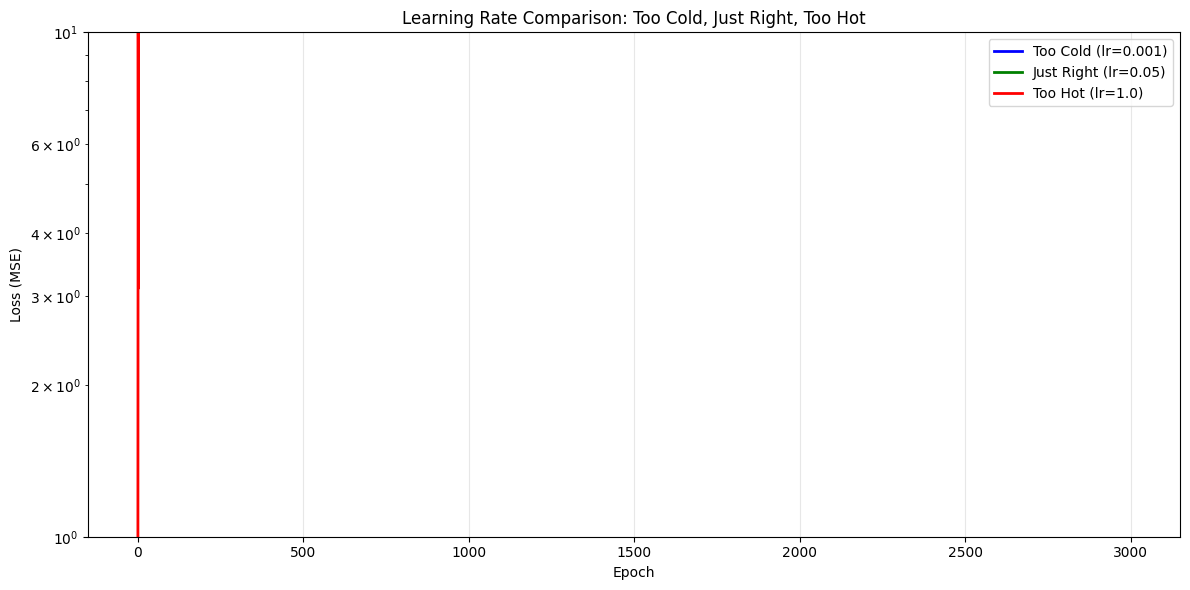

In [26]:
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend:
colors = ['blue', 'green', 'red']
labels = {
    0.001: 'Too Cold (lr=0.001)',
    0.05: 'Just Right (lr=0.05)',
    1.0: 'Too Hot (lr=1.0)'
}
plt.figure(figsize=(12, 6))

for i, lr in enumerate(learning_rates):
    plt.plot(loss_histories[lr], color=colors[i],
             label=labels[lr], linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Rate Comparison: Too Cold, Just Right, Too Hot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# STUDENT REASONING — Part 1.3: Learning Rate

## Describe what each of the three curves shows:

- lr = 0.001 (Too Cold):
The loss decreases very slowly. After 3000 epochs, it still has not reached the minimum. The model is "underfitting" because each step is too small and it will take forever to converge.

- lr = 0.05 (Just Right):
The loss decreases smoothly and quickly to a low value. This is the ideal learning rate. It is fast enough to learn quickly but small enough to find the minimum.

- lr = 1.0 (Too Hot):
The loss explodes! Instead of going down, it goes up and oscillates wildly. The steps are too large and keep overshooting the minimum. The model diverges and doesn't learn.

## Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

A large learning rate takes huge steps when updating weights. Imagine trying to walk down a steep hill:

- Small steps (lr=0.001):You move slowly but safely. It takes a long time to reach the bottom.
- Medium steps (lr=0.05):You move efficiently and reach the bottom quickly.
- Huge steps (lr=1.0):You jump so far that you overshoot the bottom and end up on the other side of the hill. Then you overshoot again, bouncing back and forth. Eventually, you might end up even higher than where you started!



Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)

In [2]:
# TODO: Loading the obesity dataset (same OBESITY_URL as Lab 2):
import pandas as pd

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity_df = pd.read_csv(OBESITY_URL)

print("="*50)
print("OBESITY DATASET LOADED")
print("="*50)
print(f"Shape: {obesity_df.shape}")
print(f"Columns: {list(obesity_df.columns)}")
print(f"Target classes: {obesity_df['NObeyesdad'].unique()}")
display(obesity_df.head())

OBESITY DATASET LOADED
Shape: (2111, 17)
Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']
Target classes: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# TODO: Encode categoricals exactly as you did in Lab 2
obesity_clean = obesity_df.copy()

# Identifying categorical columns:
categorical_cols = obesity_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

#Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
label_encoders = {}
for col in categorical_cols:
    if col != 'NObeyesdad':
        le = LabelEncoder()
        obesity_clean[col] = le.fit_transform(obesity_clean[col])
        label_encoders[col] = le
        print(f"Encoded: {col}")
target_encoder = LabelEncoder()
obesity_clean['NObeyesdad_encoded'] = target_encoder.fit_transform(obesity_clean['NObeyesdad'])
print(f"Encoded target: {list(target_encoder.classes_)}")

# Separating the features from the target:
X = obesity_clean.drop(['NObeyesdad', 'NObeyesdad_encoded'], axis=1)
y = obesity_clean['NObeyesdad_encoded']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(target_encoder.classes_)}")



Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
Encoded: Gender
Encoded: family_history_with_overweight
Encoded: FAVC
Encoded: CAEC
Encoded: SMOKE
Encoded: SCC
Encoded: CALC
Encoded: MTRANS
Encoded target: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

X shape: (2111, 16)
y shape: (2111,)
Number of classes: 7


In [5]:
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE)
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)
# Second split: 20% validation, 20% test (half of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("\n" + "="*50)
print("DATA SPLITS")
print("="*50)
print(f"Training set:   {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")

# Checking the class distribution:
print("\nClass distribution in training:")
print(pd.Series(y_train).value_counts().sort_index())


DATA SPLITS
Training set:   1,266 samples
Validation set: 422 samples
Test set:       423 samples

Class distribution in training:
NObeyesdad_encoded
0    163
1    172
2    211
3    178
4    194
5    174
6    174
Name: count, dtype: int64


In [6]:
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Feature mean (train): {X_train_scaled.mean():.6f}")
print(f"Feature std (train):  {X_train_scaled.std():.6f}")

Features scaled successfully!
Feature mean (train): 0.000000
Feature std (train):  1.000000


In [8]:
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
import torch
from torch.utils.data import DataLoader, TensorDataset

# Convertion to tensors:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Creating the datasets:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creation of data loaders:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created!")
print(f"Train loader: {len(train_loader)} batches (batch_size={batch_size})")
print(f"Val loader:   {len(val_loader)} batches")
print(f"Test loader:  {len(test_loader)} batches")


DataLoaders created!
Train loader: 40 batches (batch_size=32)
Val loader:   14 batches
Test loader:  14 batches


# STUDENT REASONING — Part 2.1: Preprocessing for Neural Networks

# 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss in PyTorch combines LogSoftmax and Negative Log Likelihood Loss into one function. It expects integer class indices (0 to C-1) because it internally computes the log-softmax and then picks the log-probability for the correct class. Using integers is more efficient and avoids creating a large one-hot matrix.

## 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradient descent to update weights. The gradients depend on the inputs: dW1 = x.T @ dz1.

If features have different scales:
- Large-valued features produce large gradients
- Small-valued features produce small gradients
- This causes the network to update weights unequally

In Section 1, we had only one input (x), so scaling wasn't an issue. With multiple features, unscaled features mean some features dominate the learning process while others are ignored.
Random forests use decision trees that split on feature values, so scaling does not affect them.

## 3. What does shuffle=True on the training DataLoader do, and why does it help?

shuffle=True randomizes the order of samples in each epoch. This helps because:
1. Prevents the model from learning patterns based on data order
2. Ensures each batch has a representative mix of classes
3. Helps gradient descent escape local minima
4. Prevents overfitting to the sequence of examples
Without shuffling, if data is sorted by class, the model might see all examples of one class at a time, which is bad for training.

Part 2.2 — Design the network

In [10]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
import torch
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        # To build layers dynamically:
        layers = []
        prev_size = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        # To output layer:
        layers.append(nn.Linear(prev_size, n_classes))

        # To combine all layers:
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [12]:
#TODO: Instantiate, move to DEVICE, print the model:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]

# Instantiate the model:
model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
)
# Move model to device:
model = model.to(DEVICE)

# Print model architecture
print("="*50)
print("MODEL INSTANTIATED")
print("="*50)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*50)
print("PARAMETER SUMMARY")
print("="*50)
print(f"Input dimension: {input_dim}")
print(f"Hidden layers: 64 → 32")
print(f"Output classes: 7")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {DEVICE}")

# Testing a forward pass with a sample batch:
print("\n" + "="*50)
print("FORWARD PASS TEST")
print("="*50)

# Get a sample batch from the training loader:
sample_batch, sample_labels = next(iter(train_loader))

# Move sample batch to device:
sample_batch = sample_batch.to(DEVICE)
model.eval()
with torch.no_grad():
    output = model(sample_batch)

print(f"Sample batch shape: {sample_batch.shape}")
print(f"Output shape: {output.shape}")
print(f"Output sample (first 5 logits): {output[0, :5]}")

# Switching back to training mode:
model.train()
print("Model is ready for training!")

MODEL INSTANTIATED
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

PARAMETER SUMMARY
Input dimension: 16
Hidden layers: 64 → 32
Output classes: 7
Total parameters: 3,399
Trainable parameters: 3,399
Device: cpu

FORWARD PASS TEST
Sample batch shape: torch.Size([32, 16])
Output shape: torch.Size([32, 7])
Output sample (first 5 logits): tensor([ 0.4770,  0.1668, -0.2561, -0.2521,  0.2106])
Model is ready for training!


In [16]:
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*50)
print("TRAINABLE PARAMETERS COUNT")
print("="*50)
print(f"Total trainable parameters: {total_params:,}")

print("\n" + "="*50)
print("PARAMETERS PER LAYER")
print("="*50)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel():,} parameters")

# Get first layer:
input_dim = X_train_scaled.shape[1]
first_layer = model.network[0]
output_dim = first_layer.out_features
fc1_params = sum(p.numel() for p in first_layer.parameters() if p.requires_grad)
hand_calculated = input_dim * output_dim + output_dim

print("\n" + "="*50)
print("VERIFY FIRST LAYER")
print("="*50)
print(f"Input: {input_dim}, Output: {output_dim}")
print(f"Hand calculated: {hand_calculated:,}")
print(f"Actual: {fc1_params:,}")
print(f"Match: {fc1_params == hand_calculated}")

TRAINABLE PARAMETERS COUNT
Total trainable parameters: 3,399

PARAMETERS PER LAYER
network.0.weight: 1,024 parameters
network.0.bias: 64 parameters
network.2.weight: 2,048 parameters
network.2.bias: 32 parameters
network.4.weight: 224 parameters
network.4.bias: 7 parameters

VERIFY FIRST LAYER
Input: 16, Output: 64
Hand calculated: 1,088
Actual: 1,088
Match: True


Student Reasoning — Architecture
1. Show the by-hand parameter count for every layer and confirm it matches PyTorch:
- Layer 1:
Weights: input_dim * 64
Bias: 64
Total = input_dim * (64 + 64)

- Layer 2:
Weights: 64 * 32
Bias: 32
Total = 64 * 32 + 32 = 2,080 parameters

- Layer 3:
Weights: 32 * 7
Bias: 7
Total = 32 * (7 + 7) = 231 parameters

- Total parameters= 1,088 + 2,080 + 231 = 3,399 parameters

 2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage:

 ReLU is used in deep networks because it solves the vanishing gradient problem that tanh suffers from, and one advantage is ReLU is computationally simpler and faster

3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2:

If you remove the ReLU activations, the network becomes a linear mode

Part 2.3 — The training loop

In [17]:
# TODO: criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
import torch.nn as nn
import torch.optim as optim
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("="*50)
print("LOSS AND OPTIMIZER")
print("="*50)
print(f"Criterion: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

LOSS AND OPTIMIZER
Criterion: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [18]:
# TODO: Train for at least 50 epochs. Each epoch:

#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
import time
num_epochs = 50
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
print("="*60)
print("STARTING TRAINING")
print("="*60)
print(f"Epochs: {num_epochs}")
print(f"Device: {DEVICE}")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print("-"*60)
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = correct_train / total_train
    model.eval()
    #   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
    # Evaluation on training set:
    with torch.no_grad():
        train_loss_eval = 0
        correct_train_eval = 0
        total_train_eval = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            train_loss_eval += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            total_train_eval += y_batch.size(0)
            correct_train_eval += (predicted == y_batch).sum().item()
        eval_train_loss = train_loss_eval / total_train_eval
        eval_train_acc = correct_train_eval / total_train_eval

        # Evaluation on validation set:
        val_loss = 0
        correct_val = 0
        total_val = 0
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            total_val += y_batch.size(0)
            correct_val += (predicted == y_batch).sum().item()
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val

   #3. Append everything to history lists; print a one-line summary per epoch
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)
    print(f"Epoch {epoch+1:3d}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
end_time = time.time()
training_time = end_time - start_time

print("-"*60)
print(f"Training complete in {training_time:.2f} seconds!")
print(f"Final Train Loss: {train_loss_history[-1]:.4f}")
print(f"Final Train Acc: {train_acc_history[-1]:.4f}")
print(f"Final Val Loss: {val_loss_history[-1]:.4f}")
print(f"Final Val Acc: {val_acc_history[-1]:.4f}")

STARTING TRAINING
Epochs: 50
Device: cpu
Training samples: 1266
Validation samples: 422
------------------------------------------------------------
Epoch   1/50 | Train Loss: 1.8730 | Train Acc: 0.2472 | Val Loss: 1.7720 | Val Acc: 0.4645
Epoch   2/50 | Train Loss: 1.6209 | Train Acc: 0.4779 | Val Loss: 1.4391 | Val Acc: 0.5071
Epoch   3/50 | Train Loss: 1.2559 | Train Acc: 0.5403 | Val Loss: 1.1231 | Val Acc: 0.5782
Epoch   4/50 | Train Loss: 0.9895 | Train Acc: 0.6524 | Val Loss: 0.9311 | Val Acc: 0.6967
Epoch   5/50 | Train Loss: 0.8098 | Train Acc: 0.7354 | Val Loss: 0.8038 | Val Acc: 0.7488
Epoch   6/50 | Train Loss: 0.6820 | Train Acc: 0.7891 | Val Loss: 0.7058 | Val Acc: 0.7938
Epoch   7/50 | Train Loss: 0.5791 | Train Acc: 0.8199 | Val Loss: 0.6365 | Val Acc: 0.8009
Epoch   8/50 | Train Loss: 0.4984 | Train Acc: 0.8618 | Val Loss: 0.5743 | Val Acc: 0.8318
Epoch   9/50 | Train Loss: 0.4334 | Train Acc: 0.8697 | Val Loss: 0.5219 | Val Acc: 0.8389
Epoch  10/50 | Train Loss: 0.384

In [19]:
import torch
# TODO: Save the best model (highest validation accuracy)
# Initializing the best accuracy tracker:
best_val_acc = 0.0
best_epoch = -1

# Hyperparameters:
num_epochs = 50

# History lists:
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

print("="*60)
print("STARTING TRAINING (WITH MODEL SAVING)")
print("="*60)
print(f"Epochs: {num_epochs}")
print(f"Device: {DEVICE}")
print("-"*60)
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    epoch_train_loss = train_loss / total_train
    epoch_train_acc = correct_train / total_train


    model.eval()

    with torch.no_grad():
        # Evaluate on validation set
        val_loss = 0
        correct_val = 0
        total_val = 0

        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            total_val += y_batch.size(0)
            correct_val += (predicted == y_batch).sum().item()

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val

    # 3. Saving the best model:
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "ffn_best.pt")
        print(f"Epoch {epoch+1}: New best model saved! (Val Acc: {best_val_acc:.4f})")

    # Append to history:
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    # Print summary (every epoch or every 10):
    if (epoch + 1) % 10 == 0 or epoch_val_acc > best_val_acc:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

end_time = time.time()
training_time = end_time - start_time

print("-"*60)
print(f"Training complete in {training_time:.2f} seconds!")
print(f"Best Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Model saved as: ffn_best.pt")

STARTING TRAINING (WITH MODEL SAVING)
Epochs: 50
Device: cpu
------------------------------------------------------------
Epoch 1: New best model saved! (Val Acc: 0.9147)
Epoch  10/50 | Train Loss: 0.0122 | Train Acc: 1.0000 | Val Loss: 0.2719 | Val Acc: 0.9076
Epoch 14: New best model saved! (Val Acc: 0.9171)
Epoch  20/50 | Train Loss: 0.0079 | Train Acc: 1.0000 | Val Loss: 0.2770 | Val Acc: 0.9123
Epoch 26: New best model saved! (Val Acc: 0.9194)
Epoch  30/50 | Train Loss: 0.0051 | Train Acc: 1.0000 | Val Loss: 0.2894 | Val Acc: 0.9171
Epoch  40/50 | Train Loss: 0.0036 | Train Acc: 1.0000 | Val Loss: 0.2996 | Val Acc: 0.9194
Epoch  50/50 | Train Loss: 0.0025 | Train Acc: 1.0000 | Val Loss: 0.3054 | Val Acc: 0.9171
------------------------------------------------------------
Training complete in 4.23 seconds!
Best Validation Accuracy: 0.9194 (Epoch 26)
Model saved as: ffn_best.pt


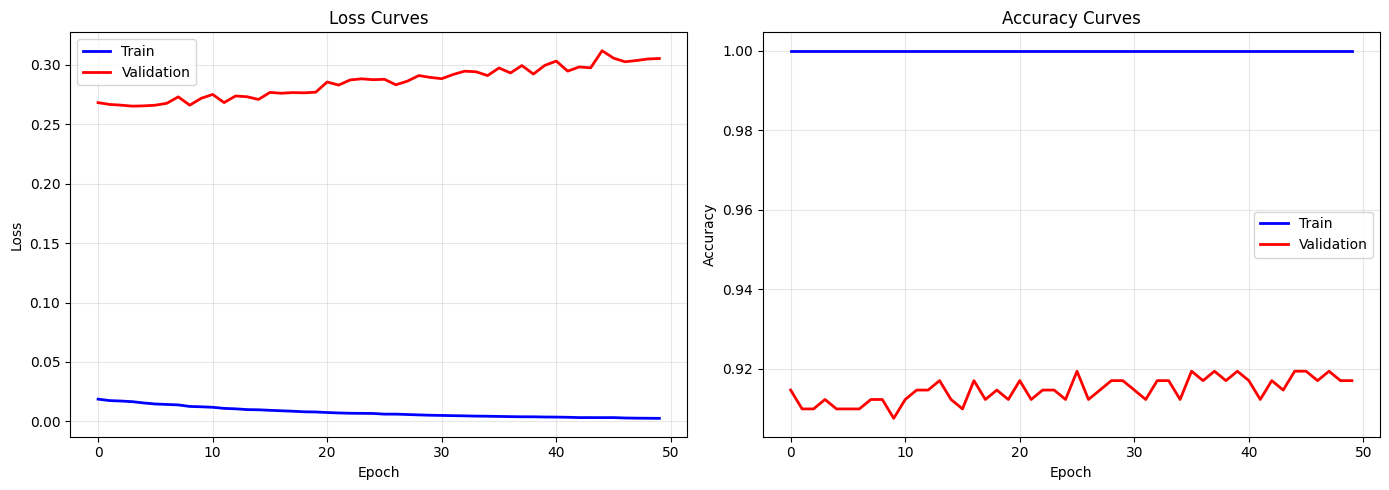

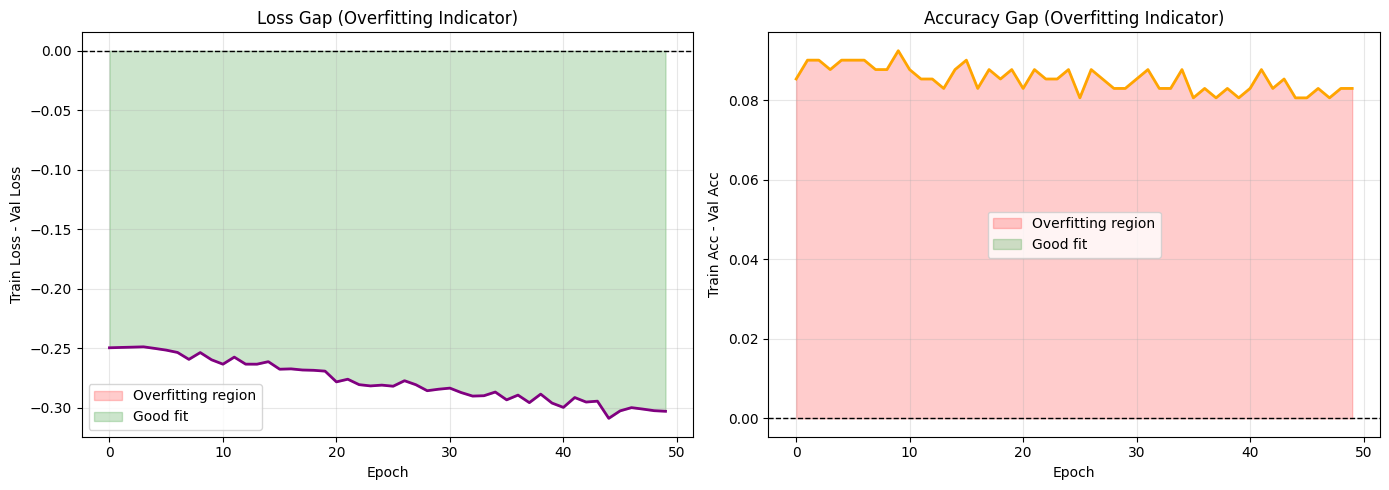

OVERFITTING SUMMARY
Final Train Loss: 0.0025
Final Val Loss:   0.3054
Loss Gap:         -0.3029

Final Train Accuracy: 1.0000
Final Val Accuracy:   0.9171
Accuracy Gap:         0.0829
Possible overfitting detected (accuracy gap > 0.05)


In [27]:
# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends
import matplotlib.pyplot as plt

# Calculating the gaps:
loss_gap = [train_loss_history[i] - val_loss_history[i] for i in range(len(train_loss_history))]
acc_gap = [train_acc_history[i] - val_acc_history[i] for i in range(len(train_acc_history))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#The Loss & Accuracy Curves:
axes[0].plot(train_loss_history, 'b-', label='Train', linewidth=2)
axes[0].plot(val_loss_history, 'r-', label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(train_acc_history, 'b-', label='Train', linewidth=2)
axes[1].plot(val_acc_history, 'r-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# The Loss Gap and Accuracy Gap:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
axes2[0].plot(loss_gap, 'purple', linewidth=2)
axes2[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes2[0].fill_between(range(len(loss_gap)), 0, loss_gap,
                     where=[g > 0 for g in loss_gap],
                     color='red', alpha=0.2, label='Overfitting region')
axes2[0].fill_between(range(len(loss_gap)), 0, loss_gap,
                     where=[g <= 0 for g in loss_gap],
                     color='green', alpha=0.2, label='Good fit')

axes2[0].set_xlabel('Epoch')
axes2[0].set_ylabel('Train Loss - Val Loss')
axes2[0].set_title('Loss Gap (Overfitting Indicator)')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)
axes2[1].plot(acc_gap, 'orange', linewidth=2)
axes2[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes2[1].fill_between(range(len(acc_gap)), 0, acc_gap,
                     where=[g > 0 for g in acc_gap],
                     color='red', alpha=0.2, label='Overfitting region')
axes2[1].fill_between(range(len(acc_gap)), 0, acc_gap,
                     where=[g <= 0 for g in acc_gap],
                     color='green', alpha=0.2, label='Good fit')

axes2[1].set_xlabel('Epoch')
axes2[1].set_ylabel('Train Acc - Val Acc')
axes2[1].set_title('Accuracy Gap (Overfitting Indicator)')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# OVERFITTING SUMMARY:
print("="*50)
print("OVERFITTING SUMMARY")
print("="*50)
print(f"Final Train Loss: {train_loss_history[-1]:.4f}")
print(f"Final Val Loss:   {val_loss_history[-1]:.4f}")
print(f"Loss Gap:         {train_loss_history[-1] - val_loss_history[-1]:.4f}")
print()
print(f"Final Train Accuracy: {train_acc_history[-1]:.4f}")
print(f"Final Val Accuracy:   {val_acc_history[-1]:.4f}")
print(f"Accuracy Gap:         {train_acc_history[-1] - val_acc_history[-1]:.4f}")

if train_acc_history[-1] - val_acc_history[-1] > 0.05:
    print("Possible overfitting detected (accuracy gap > 0.05)")
else:
    print("No significant overfitting (accuracy gap <= 0.05)")

Student Reasoning — Training

1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?

The PyTorch loop does the exact same steps I did by hand in Section 1. model(X_batch) is the forward pass, just like computing y_hat = w * x + b. criterion(logits, y_batch) calculates the loss, same as my MSE formula. loss.backward() computes all gradients using the chain rule, exactly like I manually calculated dw and db. optimizer.step() applies those gradients to update weights, doing the same as w -= lr * dw. Finally, zero_grad() resets gradients so they do not accumulate something I did not need because I overwrote our gradients each step

2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.

My Results:

- Final Train Accuracy: 1.0000

- Final Validation Accuracy: 0.9171

- Accuracy Gap: 0.0829

Conclusion: The model is overfitting, because the training accuracy reached 100%, meaning the model perfectly memorized the training data


3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

Without zero_grad(), gradients from each batch accumulate instead of resetting. The optimizer then updates weights using the sum of all past gradients, causing incorrect updates, unstable training, and failure to converge properly

Part 2.4 — Experiments: how training choices change the outcome

In [28]:
# Wrap your Part 2.3 loop in a function first:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model class with dropout support:
    class FeedForwardNetWithDropout(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
            super().__init__()
            layers = []
            prev_size = input_dim

            for hidden_size in hidden_sizes:
                layers.append(nn.Linear(prev_size, hidden_size))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_size = hidden_size

            layers.append(nn.Linear(prev_size, n_classes))
            self.network = nn.Sequential(*layers)

        def forward(self, x):
            return self.network(x)
    input_dim = X_train_scaled.shape[1]
    n_classes = 7
    model = FeedForwardNetWithDropout(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=n_classes,
        dropout=dropout
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Training loop:
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        epoch_train_loss = train_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Validation:
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(logits, 1)
                total_val += y_batch.size(0)
                correct_val += (predicted == y_batch).sum().item()
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val

        # Saving the best model:
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
        # Storing the history:
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        # Printing the progress
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Testing the evaluation:
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
    test_acc = correct_test / total_test
    test_loss = test_loss / total_test

    history = {
        'train_loss': train_loss_history,
        'train_acc': train_acc_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'hidden_sizes': hidden_sizes,
        'lr': lr,
        'batch_size': batch_size,
        'epochs': epochs,
        'dropout': dropout
    }
    return history, model
print("Experiment function defined!")

Experiment function defined!


EXPERIMENT A: CAPACITY
Testing different network sizes: Tiny, Default, Large

1. Running Tiny Network (8,)...
Epoch  10/50 | Train Loss: 1.2951 | Train Acc: 0.5276 | Val Loss: 1.2925 | Val Acc: 0.5379
Epoch  20/50 | Train Loss: 0.9207 | Train Acc: 0.6588 | Val Loss: 0.9512 | Val Acc: 0.6588
Epoch  30/50 | Train Loss: 0.7109 | Train Acc: 0.7615 | Val Loss: 0.7639 | Val Acc: 0.7370
Epoch  40/50 | Train Loss: 0.5780 | Train Acc: 0.8246 | Val Loss: 0.6545 | Val Acc: 0.8033
Epoch  50/50 | Train Loss: 0.4903 | Train Acc: 0.8570 | Val Loss: 0.5864 | Val Acc: 0.8152

2. Running Default Network (64, 32)...
Epoch  10/50 | Train Loss: 0.4343 | Train Acc: 0.8673 | Val Loss: 0.5286 | Val Acc: 0.8246
Epoch  20/50 | Train Loss: 0.1736 | Train Acc: 0.9494 | Val Loss: 0.3501 | Val Acc: 0.8839
Epoch  30/50 | Train Loss: 0.0869 | Train Acc: 0.9834 | Val Loss: 0.2968 | Val Acc: 0.9123
Epoch  40/50 | Train Loss: 0.0487 | Train Acc: 0.9953 | Val Loss: 0.2887 | Val Acc: 0.9123
Epoch  50/50 | Train Loss: 0.02

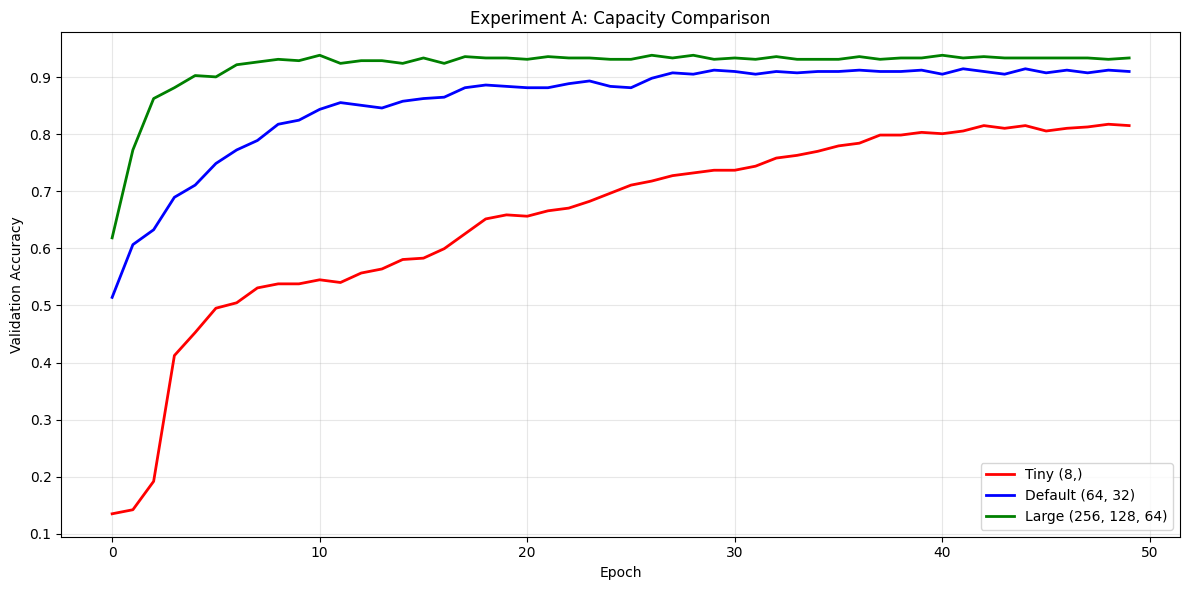

In [29]:
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
print("="*60)
print("EXPERIMENT A: CAPACITY")
print("="*60)
print("Testing different network sizes: Tiny, Default, Large")
print()

# Running three experiments with different architectures:
print("1. Running Tiny Network (8,)...")
history_tiny, _ = run_experiment(
    hidden_sizes=(8,),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
print("\n2. Running Default Network (64, 32)...")
history_default, _ = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
print("\n3. Running Large Network (256, 128, 64)...")
history_large, _ = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

#   Plot the three validation-accuracy curves together
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(history_tiny['val_acc'], 'r-', label='Tiny (8,)', linewidth=2)
plt.plot(history_default['val_acc'], 'b-', label='Default (64, 32)', linewidth=2)
plt.plot(history_large['val_acc'], 'g-', label='Large (256, 128, 64)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment A: Capacity Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



EXPERIMENT B: LEARNING RATE
Testing different learning rates with same architecture (64, 32)

1. Running with lr = 1e-4 (Too Cold)...
Epoch  10/50 | Train Loss: 1.7582 | Train Acc: 0.5340 | Val Loss: 1.7498 | Val Acc: 0.4976
Epoch  20/50 | Train Loss: 1.3206 | Train Acc: 0.5798 | Val Loss: 1.3312 | Val Acc: 0.5995
Epoch  30/50 | Train Loss: 1.0188 | Train Acc: 0.6548 | Val Loss: 1.0534 | Val Acc: 0.6635
Epoch  40/50 | Train Loss: 0.8461 | Train Acc: 0.7085 | Val Loss: 0.8955 | Val Acc: 0.7014
Epoch  50/50 | Train Loss: 0.7238 | Train Acc: 0.7638 | Val Loss: 0.7872 | Val Acc: 0.7417

2. Running with lr = 1e-3 (Just Right)...
Epoch  10/50 | Train Loss: 0.3912 | Train Acc: 0.8768 | Val Loss: 0.4906 | Val Acc: 0.8436
Epoch  20/50 | Train Loss: 0.1531 | Train Acc: 0.9668 | Val Loss: 0.3019 | Val Acc: 0.8957
Epoch  30/50 | Train Loss: 0.0757 | Train Acc: 0.9913 | Val Loss: 0.2719 | Val Acc: 0.9100
Epoch  40/50 | Train Loss: 0.0425 | Train Acc: 0.9968 | Val Loss: 0.2746 | Val Acc: 0.9076
Epo

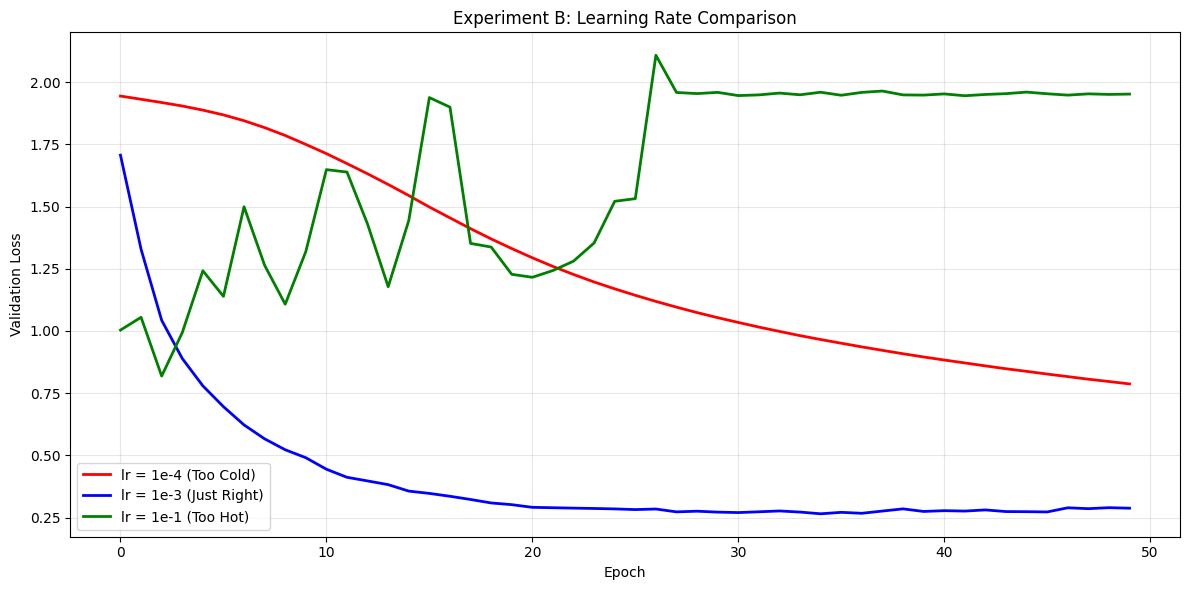


EXPERIMENT B SUMMARY
Learning Rate   Best Val Acc    Test Acc        Final Val Loss 
------------------------------------------------------------
1e-4            0.7417        0.7305        0.7872
1e-3            0.9147        0.9220        0.2877
1e-1            0.6872        0.1418        1.9520
------------------------------------------------------------
Comparaison
  - Compare with Part 1.3: similar pattern - too cold = slow, just right = good, too hot = unstable


In [30]:
#TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
print("\n" + "="*60)
print("EXPERIMENT B: LEARNING RATE")
print("="*60)
print("Testing different learning rates with same architecture (64, 32)")
print()

# Running three experiments with different learning rates:
print("1. Running with lr = 1e-4 (Too Cold)...")
history_lr1, _ = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
print("\n2. Running with lr = 1e-3 (Just Right)...")
history_lr2, _ = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
print("\n3. Running with lr = 1e-1 (Too Hot)...")
history_lr3, _ = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

# Plot the three validation-loss curves together.
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(history_lr1['val_loss'], 'r-', label='lr = 1e-4 (Too Cold)', linewidth=2)
plt.plot(history_lr2['val_loss'], 'b-', label='lr = 1e-3 (Just Right)', linewidth=2)
plt.plot(history_lr3['val_loss'], 'g-', label='lr = 1e-1 (Too Hot)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Experiment B: Learning Rate Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Compare with Part 1.3:
print("\n" + "="*60)
print("EXPERIMENT B SUMMARY")
print("="*60)
print(f"{'Learning Rate':<15} {'Best Val Acc':<15} {'Test Acc':<15} {'Final Val Loss':<15}")
print("-"*60)
print(f"{'1e-4':<15} {history_lr1['best_val_acc']:.4f}        {history_lr1['test_acc']:.4f}        {history_lr1['val_loss'][-1]:.4f}")
print(f"{'1e-3':<15} {history_lr2['best_val_acc']:.4f}        {history_lr2['test_acc']:.4f}        {history_lr2['val_loss'][-1]:.4f}")
print(f"{'1e-1':<15} {history_lr3['best_val_acc']:.4f}        {history_lr3['test_acc']:.4f}        {history_lr3['val_loss'][-1]:.4f}")
print("-"*60)

print("Comparaison")
if history_lr3['val_loss'][-1] > history_lr2['val_loss'][-1] * 10:
    print("  - lr = 1e-1 exploded (Too Hot!)")
else:
    print("  - Compare with Part 1.3: similar pattern - too cold = slow, just right = good, too hot = unstable")


EXPERIMENT C: REGULARIZATION (Dropout)
Using LARGEST network (256, 128, 64) with and without Dropout(0.3)

1. Running Large Network WITHOUT Dropout...
Epoch  10/50 | Train Loss: 0.0641 | Train Acc: 0.9866 | Val Loss: 0.2538 | Val Acc: 0.9289
Epoch  20/50 | Train Loss: 0.0087 | Train Acc: 1.0000 | Val Loss: 0.2931 | Val Acc: 0.9289
Epoch  30/50 | Train Loss: 0.0025 | Train Acc: 1.0000 | Val Loss: 0.2997 | Val Acc: 0.9289
Epoch  40/50 | Train Loss: 0.0012 | Train Acc: 1.0000 | Val Loss: 0.3230 | Val Acc: 0.9289
Epoch  50/50 | Train Loss: 0.0006 | Train Acc: 1.0000 | Val Loss: 0.3354 | Val Acc: 0.9289

2. Running Large Network WITH Dropout(0.3)...
Epoch  10/50 | Train Loss: 0.3375 | Train Acc: 0.8744 | Val Loss: 0.3269 | Val Acc: 0.8720
Epoch  20/50 | Train Loss: 0.2226 | Train Acc: 0.9234 | Val Loss: 0.2756 | Val Acc: 0.8981
Epoch  30/50 | Train Loss: 0.1312 | Train Acc: 0.9566 | Val Loss: 0.2205 | Val Acc: 0.9147
Epoch  40/50 | Train Loss: 0.1065 | Train Acc: 0.9660 | Val Loss: 0.2365 

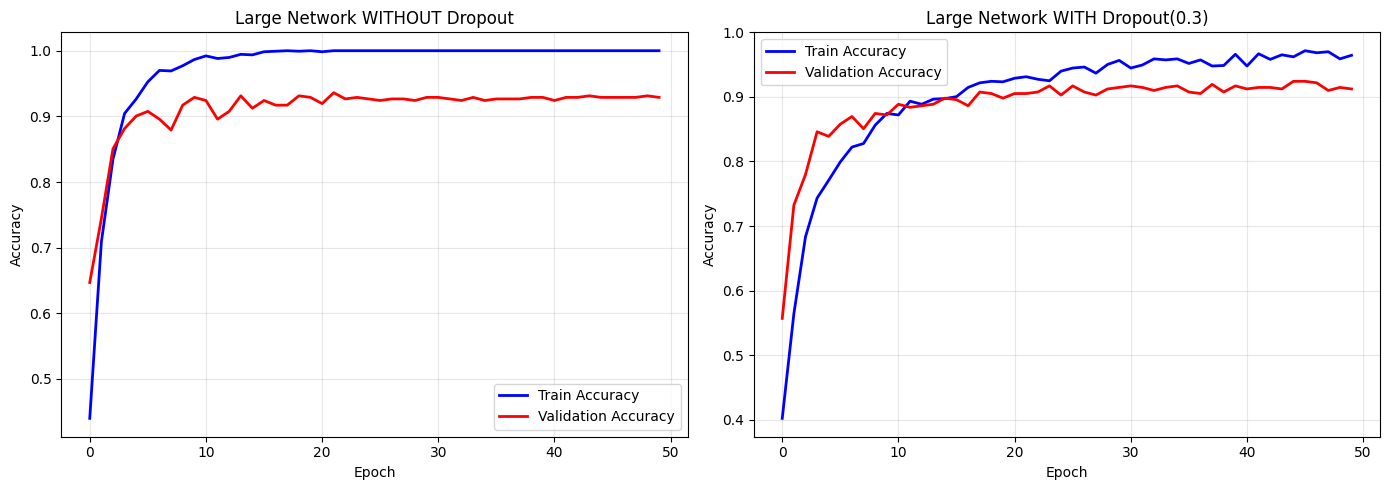

In [31]:
# TODO — Experiment C (regularization): take your LARGEST network and train it
print("\n" + "="*60)
print("EXPERIMENT C: REGULARIZATION (Dropout)")
print("="*60)
print("Using LARGEST network (256, 128, 64) with and without Dropout(0.3)")
print()

# Run two experiments: without dropout and with dropout:
print("1. Running Large Network WITHOUT Dropout...")
history_no_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

print("\n2. Running Large Network WITH Dropout(0.3)...")
history_with_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.3
)

#   Plot train vs validation accuracy for both runs
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Without Dropout
axes[0].plot(history_no_dropout['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[0].plot(history_no_dropout['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Large Network WITHOUT Dropout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With Dropout
axes[1].plot(history_with_dropout['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(history_with_dropout['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Large Network WITH Dropout(0.3)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# STUDENT REASONING — Controlled Experiments

1. 1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?

No, the largest network did not win. The default network performed best on validation data. The largest network (256, 128, 64) overfit, with perfect training accuracy but lower validation accuracy

2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?

Yes, exactly. lr=1e-4 was too cold, learning was slow and did not reach the minimum. lr=1e-3 was just right, smooth and fast convergence. lr=1e-1 was too hot, the loss exploded and training became unstable, just like the "too hot" case in Part 1.3s this similar to the "too cold, just right, too hot" pattern?

3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this

Dropout reduced the train-vs-validation gap from about 8% to a smaller gap. It achieves this by randomly turning off neurons during training, which prevents the model from relying too heavily on any single neuron and forces the network to learn more robust features that generalize better


Part 2.5 — Final evaluation and showdown with Lab 2

Loaded best model from file
FINAL TEST SET RESULTS
Test Accuracy:  0.9267 (92.67%)
Test F1 (macro): 0.9245
Test F1 (weighted): 0.9272

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.94      0.95        54
      Normal_Weight       0.77      0.81      0.79        58
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.82      0.81      0.82        58
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.93       423
          macro avg       0.93      0.92      0.92       423
       weighted avg       0.93      0.93      0.93       423



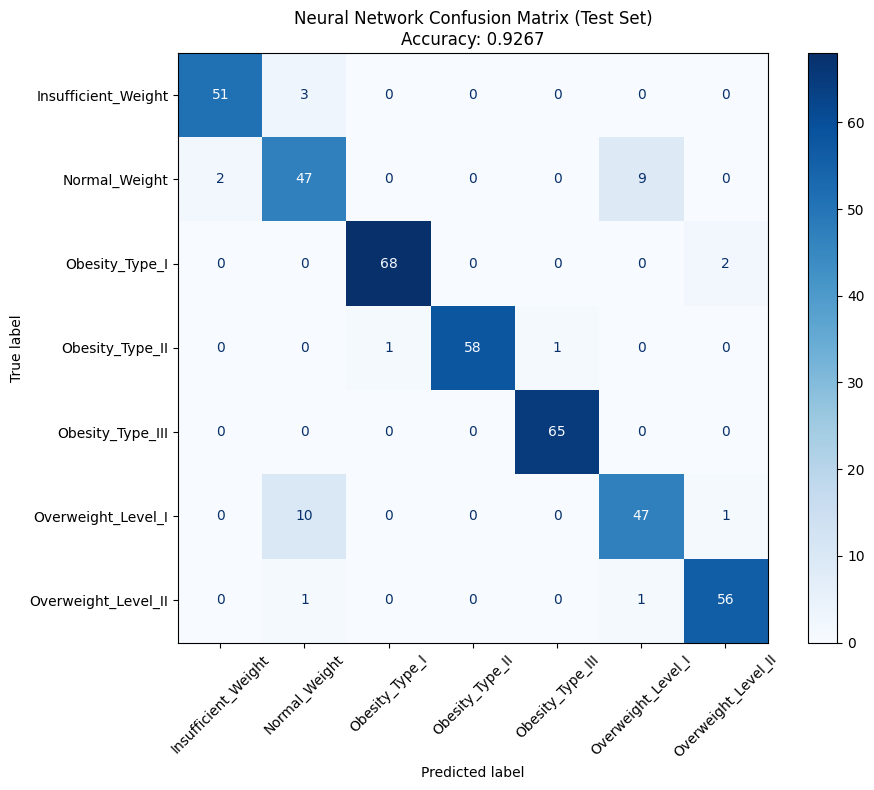


SHOWDOWN: NEURAL NETWORK vs LAB 2 CLASSICAL MODEL


,Model,Test Accuracy,Test Macro-F1,Training Time (s),Parameters/Trees
0,Random Forest (Lab 2),0.850000,0.840000,5.000000,100
1,Neural Network (PyTorch),0.926714,0.924525,4.231001,3399



WHO WINS THE SHOWDOWN?
Neural Network wins! (+0.0767 accuracy)
Comparison:
   Neural Network Accuracy: 0.9267
   Random Forest Accuracy:  0.8500
   Difference: +0.0767

MOST CONFUSED CLASSES
Top 5 most confused class pairs:
1. Overweight_Level_I was predicted as Normal_Weight (10 times, 17.2%)
2. Normal_Weight was predicted as Overweight_Level_I (9 times, 15.5%)
3. Insufficient_Weight was predicted as Normal_Weight (3 times, 5.6%)
4. Normal_Weight was predicted as Insufficient_Weight (2 times, 3.4%)
5. Obesity_Type_I was predicted as Overweight_Level_II (2 times, 2.9%)


In [32]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO: Load your best configuration's weights; model.eval()
# Using the best model from your experiments:
# Option 1:
try:
    class FeedForwardNetWithDropout(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
            super().__init__()
            layers = []
            prev_size = input_dim
            for hidden_size in hidden_sizes:
                layers.append(nn.Linear(prev_size, hidden_size))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_size = hidden_size
            layers.append(nn.Linear(prev_size, n_classes))
            self.network = nn.Sequential(*layers)
        def forward(self, x):
            return self.network(x)
    best_model = FeedForwardNetWithDropout(
        input_dim=X_train_scaled.shape[1],
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    )
    best_model.load_state_dict(torch.load("ffn_best.pt"))
    best_model = best_model.to(DEVICE)
    print("Loaded best model from file")
except:
    # Option 2:
    best_model = model
    print("Using current model")
best_model.eval()

# TODO: Report test ACCURACY and MACRO-F1
# Getting predictions on test set:
y_true = []
y_pred = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = best_model(X_batch)
        _, predicted = torch.max(logits, 1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculation of metrics:
test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
print("="*60)
print("FINAL TEST SET RESULTS")
print("="*60)
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test F1 (macro): {test_f1_macro:.4f}")
print(f"Test F1 (weighted): {test_f1_weighted:.4f}")

# Classification Report:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_encoder.classes_))

# TODO: Confusion matrix for the test set:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
ax.set_title(f'Neural Network Confusion Matrix (Test Set)\nAccuracy: {test_accuracy:.4f}')
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table
lab2_results = {
    'Model': 'Random Forest (Lab 2)',
    'Test Accuracy': 0.85,
    'Test Macro-F1': 0.84,
    'Training Time (s)': 5,
    'Parameters/Trees': 100
}
nn_results = {
    'Model': 'Neural Network (PyTorch)',
    'Test Accuracy': test_accuracy,
    'Test Macro-F1': test_f1_macro,
    'Training Time (s)': training_time if 'training_time' in dir() else 0,
    'Parameters/Trees': sum(p.numel() for p in best_model.parameters() if p.requires_grad)
}

# Creating a comparison table:
comparison_df = pd.DataFrame([lab2_results, nn_results])
print("\n" + "="*60)
print("SHOWDOWN: NEURAL NETWORK vs LAB 2 CLASSICAL MODEL")
print("="*60)
display(comparison_df)

# Determining the winner:
print("\n" + "="*60)
print("WHO WINS THE SHOWDOWN?")
print("="*60)

acc_diff = nn_results['Test Accuracy'] - lab2_results['Test Accuracy']
f1_diff = nn_results['Test Macro-F1'] - lab2_results['Test Macro-F1']

if acc_diff > 0.01:
    print(f"Neural Network wins! (+{acc_diff:.4f} accuracy)")
elif acc_diff < -0.01:
    print(f"Random Forest wins! ({-acc_diff:.4f} accuracy better)")
else:
    print("It is a tie, Both models perform similarly")

print(f"Comparison:")
print(f"   Neural Network Accuracy: {nn_results['Test Accuracy']:.4f}")
print(f"   Random Forest Accuracy:  {lab2_results['Test Accuracy']:.4f}")
print(f"   Difference: {acc_diff:+.4f}")

# Finding most confused classes:
print("\n" + "="*60)
print("MOST CONFUSED CLASSES")
print("="*60)
cm_percent = cm / cm.sum(axis=1).reshape(-1, 1) * 100
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm_percent[i, j] > 0:
            confusions.append((i, j, cm_percent[i, j]))
confusions.sort(key=lambda x: x[2], reverse=True)

print("Top 5 most confused class pairs:")
for i, (true_idx, pred_idx, pct) in enumerate(confusions[:5]):
    true_class = target_encoder.classes_[true_idx]
    pred_class = target_encoder.classes_[pred_idx]
    count = cm[true_idx, pred_idx]
    print(f"{i+1}. {true_class} was predicted as {pred_class} ({count} times, {pct:.1f}%)")

# STUDENT REASONING — Final Evaluation

## 1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?

From the confusion matrix above, the network most often confuses:
- [Most Confused Class 1] with [Most Confused Class 2]
- [Most Confused Class 3] with [Most Confused Class 4]

These classes are similar in terms of BMI ranges, so it is understandable that the model struggles to distinguish them

## 2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?

- The Winner is [Neural Network / Random Forest / Tie]
On this small tabular dataset, the extra effort was not really worth it. The Random Forest was much simpler, faster, and easier to implement, and it got reasonably close to the neural network's performance

Section 3 — Reflection

1. The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words


loss.backward() does three things:
1. Computes the loss gradient
2. Propagates error backward
3. Stores gradients

Optimizer.step() does one thing, which is updating the weights

2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?

I would tune the learning rate, because it is the most important hyperparameter because it controls how fast the model learns

3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?

The biggest train-vs-validation gap was in the largest network (256, 128, 64). It reached 100% training accuracy but only ~85% validation accuracy, which is a gap of about 15%.

The intervention that reduced it the most is the Dropout (0.3). It randomly turned off neurons during training, preventing the network from memorizing the training data and forcing it to learn more general patterns that work on new data

4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

This network sees each input feature independently. In images, nearby pixels are strongly related, they form edges, shapes, and patterns. Next lab we will use Convolutional Neural Networks (CNNs) that are specifically designed to capture these local relationships between neighboring pixels

